## Chlorophyll Budget Near Eddy Core

In [1]:
from smode_import import *

### Budget equation:
$\frac{1}{P}\frac{D_h P}{Dt} = G - \Gamma - w \frac{\partial P}{\partial z}$

# $\frac{d (ln[Chl])}{dt}$

In [4]:
dChldt = xr.open_dataset('dChldt_from_core.nc')#.dChldt

# Change coord from dist_from_core to time
dChldt = xr.Dataset(
    {
        'dChldt': (['time'], dChldt.dChldt.values),
        'dist_from_core': (['time'], dChldt.dist_from_core.values),
        'dist_from_ship': (['time'], dChldt.dist_from_ship.values),
        'lat': (['time'], dChldt.lat.values),
        'lon': (['time'], dChldt.lon.values),
    },
    coords={'time': (['time'], dChldt.time.values)}
)
dChldt = dChldt.sortby(dChldt.time)
dChldt

<xarray.Dataset> Size: 3kB
Dimensions:         (time: 53)
Coordinates:
  * time            (time) datetime64[ns] 424B 2023-04-19T03:00:00 ... 2023-0...
Data variables:
    dChldt          (time) float64 424B 1.337 1.316 2.194 ... -1.005 -1.169
    dist_from_core  (time) float64 424B 4.008 4.765 2.258 ... 8.41 9.125 9.339
    dist_from_ship  (time) float64 424B 0.7786 0.6521 0.9095 ... 0.7711 0.8588
    lat             (time) float64 424B 37.02 37.02 36.98 ... 36.81 36.81 36.81
    lon             (time) float64 424B -123.9 -123.9 -123.9 ... -124.2 -124.2

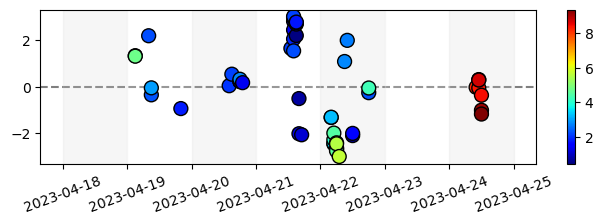

In [5]:
plt.figure(figsize=(8,2))
plt.scatter(x=dChldt.time, y=dChldt.dChldt, c=dChldt.dist_from_core, s=100, edgecolor='k', cmap='jet')
plt.colorbar()
plt.axhline(0,color='k',linestyle='--',alpha=0.5,zorder=0)
plt.xticks(rotation=20)

# Add shading between days
custom_dates = pd.date_range(start='2023-04-18', end='2023-04-25', freq='1D')  # Daily frequency
for i in range(len(custom_dates) - 1):
    start_day, end_day = custom_dates[i], custom_dates[i + 1]
    color = 'lightgrey' if i % 2 == 0 else 'white' # alternate colors
    plt.axvspan(start_day, end_day, color=color, alpha=0.2, zorder=0)


plt.show()

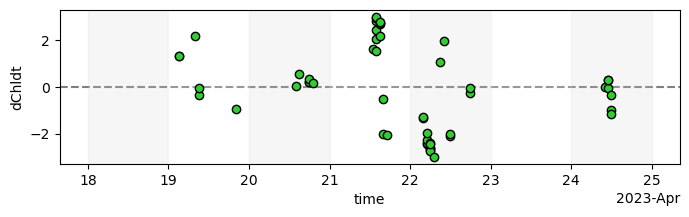

In [6]:
dChldt.dChldt.plot.scatter(x='time',edgecolor='k',facecolor='limegreen',figsize=(8,2))
plt.axhline(0,color='k',linestyle='--',alpha=0.5,zorder=0)
# Add shading between days
custom_dates = pd.date_range(start='2023-04-18', end='2023-04-25', freq='1D')  # Daily frequency
for i in range(len(custom_dates) - 1):
    start_day, end_day = custom_dates[i], custom_dates[i + 1]
    color = 'lightgrey' if i % 2 == 0 else 'white' # alternate colors
    plt.axvspan(start_day, end_day, color=color, alpha=0.2, zorder=0)

plt.show();

### $G - \Gamma$

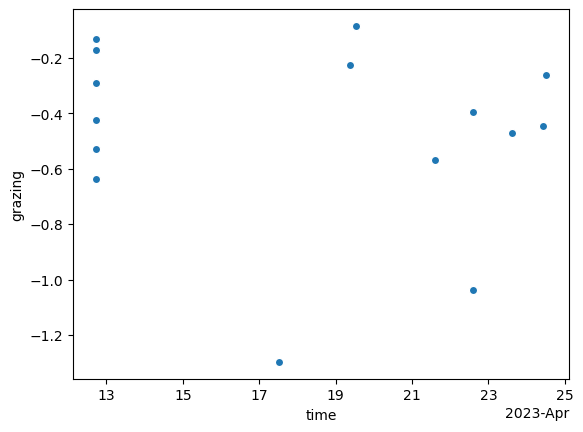

In [18]:
eddy_biology = xr.open_dataset('eddy_biology.nc')
biology_data = eddy_biology.swap_dims({'dist_from_core': 'time'})
biology_data.grazing.plot.scatter(x='time')

In [7]:
# load biology data
#biology_data = xr.open_dataset('biology_data.nc')
#biology_data=biology_data.where(biology_data.growth>0,drop=True)
#biology_data

<xarray.Dataset> Size: 2kB
Dimensions:         (time: 20)
Coordinates:
  * time            (time) datetime64[ns] 160B 2023-04-12T17:09:54 ... 2023-0...
Data variables:
    cast            (time) float64 160B 1.0 1.0 1.0 5.0 ... 16.0 17.0 20.0 20.0
    depth           (time) float64 160B 5.0 10.0 27.0 5.0 ... 10.0 5.0 5.0 10.0
    grazing         (time) float64 160B -0.7348 -0.5954 ... -1.114 -0.8734
    growth          (time) float64 160B 0.5845 0.8281 0.3071 ... 1.399 1.217
    lat             (time) float64 160B 37.02 37.02 37.02 ... 36.92 36.81 36.81
    lon             (time) float64 160B -123.8 -123.8 -123.8 ... -124.2 -124.2
    expt_ID         (time) object 160B 'Dil1C1N21' 'Dil3C1N17' ... 'Dil45C20N20'
    grazing_se      (time) float64 160B 0.1349 0.2867 0.09611 ... 0.1253 0.09824
    growth_se       (time) float64 160B 0.08794 0.1751 ... 0.08894 0.06983
    chl_a           (time) float64 160B 1.499 2.082 0.8503 ... 1.567 1.956 2.548
    dist_from_core  (time) float64 160B 221.0 221.0 221.0 ... 39.52 41.59 41.59
Attributes:
    name:     Growth and Grazing Rates

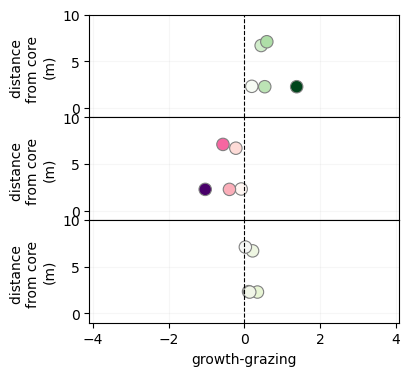

In [19]:
fig, ax = plt.subplots(3,1,figsize=(4,4), sharey=True, sharex=True, gridspec_kw={'hspace':0})

ax[0].scatter(biology_data.growth, biology_data.dist_from_core,s=80,
              c=biology_data.growth.values,cmap='Greens',edgecolor='grey',linewidth=0.8)
ax[1].scatter(biology_data.grazing,biology_data.dist_from_core,s=80,
              c=biology_data.grazing.values,cmap='RdPu_r',edgecolor='grey',linewidth=0.8)
ax[2].scatter((biology_data.growth+biology_data.grazing),biology_data.dist_from_core,s=80,
              c=(biology_data.growth+biology_data.grazing), vmin=-2,vmax=2,cmap='PiYG',edgecolor='grey',linewidth=0.8)

ax[0].set_xlabel('growth')
ax[1].set_xlabel('grazing')
ax[2].set_xlabel('growth-grazing')

for axis in ax:
    axis.grid(alpha=0.1)
    axis.axvline(0,color='k',linestyle='--',linewidth=0.8)
    axis.set_xlim(-4.1,4.1)
    axis.set_ylim(-1,10)

    axis.set_ylabel('distance \nfrom core \n(m)')
#plt.xlabel('(day-1)')
plt.show()

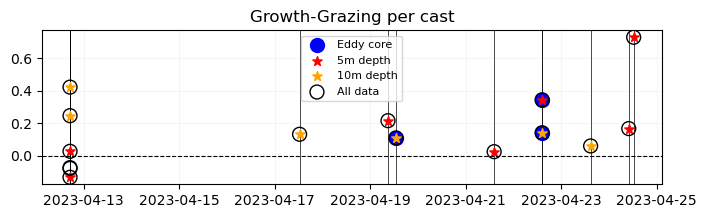

In [20]:


plt.figure(figsize=(8,2))
#plt.plot(eddy_biology.time, (eddy_biology.growth+eddy_biology.grazing), 'ok')
#plt.plot(biology_data.time, (biology_data.growth+biology_data.grazing), 'og')

dx_core = 4#km
plt.scatter(biology_data.time.where(biology_data.dist_from_core<=dx_core),
            (biology_data.growth+biology_data.grazing).where(biology_data.dist_from_core<=dx_core),
            marker='o',facecolor='b',s=100, label='Eddy core')

plt.scatter(biology_data.time.where(biology_data.depth==5),
         (biology_data.growth+biology_data.grazing).where(biology_data.depth==5),
          marker='*',facecolor='r',s=50, label='5m depth')

plt.scatter(biology_data.time.where(biology_data.depth==10),
         (biology_data.growth+biology_data.grazing).where(biology_data.depth==10),
          marker='*',facecolor='orange',s=50, label='10m depth')

plt.scatter(biology_data.time,
            (biology_data.growth+biology_data.grazing),
            marker='o',facecolor='none',edgecolor='k',s=100,label='All data')


plt.grid(alpha=0.1)
plt.title('Growth-Grazing per cast')
plt.legend(fontsize=8)
plt.axhline(0,color='k',linestyle='--',linewidth=0.8)
for cast in range(len(biology_data.time)):
    plt.axvline(pd.Timestamp(str(biology_data.time.isel(time=cast).values)),
                linestyle='-',color='k',linewidth=0.5, zorder=0)
plt.show();

In [254]:
new_=  biology_data.sel(time=slice('2023-04-19','2023-04-23'))
print(len(new_))
idx = np.where(new_.depth==5)
new_ = new_.isel(time=idx[0])
new_.dist_from_core
#growth

11


<xarray.DataArray 'dist_from_core' (time: 4)> Size: 32B
array([ 6.6995513 ,  7.10409751,  2.28684113, 15.82570899])
Coordinates:
  * time     (time) datetime64[ns] 32B 2023-04-19T09:00:00 ... 2023-04-23T14:...

## $w$

In [21]:
dopp = xr.open_dataset('dopplerscatt_gridded.nc')
div = xr.open_dataset('eddy_div_all.nc')
div

# vertical velocity
w_5m = 5*div  * 86400*coriolis_parameter(35) # ACS measurements are at 4-m depth [per day]

# Compute distance from eddy core
x_eddy, y_eddy = w_5m.x_eddy, w_5m.y_eddy
X, Y = np.meshgrid(x_eddy - x_eddy.mean(), y_eddy - y_eddy.mean(), indexing='ij')
dist_from_core = np.sqrt(X**2 + Y**2)


##
nt, nx, ny = w_5m.divergence.values.shape
w_flat = w_5m.divergence.values.reshape(nt, -1)               # shape: (nt, nx*ny)
dist_flat = dist_from_core.flatten()     # shape: (nx*ny,)

# Step 3: Define radial bins
bins = np.arange(0, 10, 0.4)           # bin edges in km
bin_centers = 0.5 * (bins[:-1] + bins[1:])
bin_indices = np.digitize(dist_flat, bins) - 1  # -1 so bin_indices align with bin_centers

# Step 4: Allocate output
w_rad_ave = np.full((nt, len(bin_centers)), np.nan)
w_rad_std = np.full((nt, len(bin_centers)), np.nan)

# Step 5: Loop over bins to average
for i in range(len(bin_centers)):
    mask = bin_indices == i  # which pixels fall in this radial bin
    if np.any(mask):
        w_rad_ave[:, i] = np.nanmean(w_flat[:, mask], axis=1)  # average over points in bin
        w_rad_std[:, i] = np.nanstd(w_flat[:, mask], axis=1)  # average over points in bin

w = xr.Dataset(
    {
        'w_radial_average': (['time','dist_from_core'], w_rad_ave),
        'w_radial_std': (['time','dist_from_core'], w_rad_std),
    },
    coords={
        'time': (['time'], w_5m.time.values),
        'dist_from_core': (['dist_from_core'], bin_centers),
    }
)
w = w.sortby(w.time)
w


<xarray.Dataset> Size: 3kB
Dimensions:           (time: 5, dist_from_core: 24)
Coordinates:
  * time              (time) <U29 580B '2023-04-19T20:25:05.000000000' ... '2...
  * dist_from_core    (dist_from_core) float64 192B 0.2 0.6 1.0 ... 8.6 9.0 9.4
Data variables:
    w_radial_average  (time, dist_from_core) float64 960B -3.569 -4.038 ... nan
    w_radial_std      (time, dist_from_core) float64 960B 1.735 3.915 ... nan

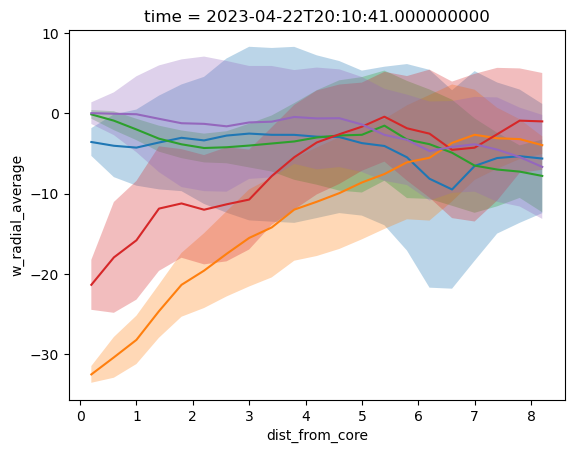

In [22]:
for i in range(5):
    w.isel(time=i).w_radial_average.plot()
    plt.fill_between(w.dist_from_core,
                     w.w_radial_average.isel(time=i)-w.w_radial_std.isel(time=i),
                     w.w_radial_average.isel(time=i)+w.w_radial_std.isel(time=i),
                     alpha=0.3)
plt.show();

## $\frac{dP}{dz}$

In [23]:
# Compute dPdz using the ACS

# ship data
mvp = xr.open_dataset('MVP.nc')

# ACS
TSG = xr.open_dataset('/Users/elise/data/SMODE-data/S_MODE_IOP2_SRIDE23_tsg_met_bio.nc')
TSG = TSG.drop_duplicates(dim='time_bio')
TSG = TSG.drop_duplicates(dim='time')
flowrate_time_bio = TSG['flow_rate_lab_tsg'].interp(time=TSG['time_bio'], method='linear')
TSG['flowrate_time_bio'] = (TSG.chlorophyll_ACS.dims, flowrate_time_bio.values)
TSG

# transects info and time periods
orientations = ['horizontal','vertical','vertical','horizontal','vertical']

# time we crossed the eddy
times_dopplerscatt=['2023-04-19T20','2023-04-20T20',
                  '2023-04-21T15','2023-04-21T21',
                  '2023-04-22T20','2023-04-24T20',]
time_crossing_intervals = [
    ['2023-04-20T03:20:00', '2023-04-20T05:00:00'],
    ['2023-04-20T21:00:00', '2023-04-20T23:00:00'],
    ['2023-04-21T16:40:00', '2023-04-21T17:25:00'],
    ['2023-04-21T18:30:00', '2023-04-21T19:26:00'],
    ['2023-04-22T21:40:00', '2023-04-22T23:40:00'],
]

time_crossing_intervals = [
    ['2023-04-19T00:00', '2023-04-24T00:00:00']
]

#orientations = orientations[2:4]
#time_crossing_intervals = time_crossing_intervals[2:4]

mvp['rho'] = mvp.rho.where(mvp.salt >= 32.5)


In [27]:
dPdz_all = []
dist_from_core_all = []
times_all = []

for itransect in range(len(time_crossing_intervals)):
    da_eddy = mvp.sel(time=slice(time_crossing_intervals[itransect][0],
                              time_crossing_intervals[itransect][1]))
    ACS_eddy = TSG['chlorophyll_ACS'].sel(time_bio=slice(time_crossing_intervals[itransect][0],
                              time_crossing_intervals[itransect][1]))
    ACS_eddy = ACS_eddy.rolling(time_bio=14,center=True,min_periods=1,).mean()
    
    icore = np.where(ACS_eddy==ACS_eddy.max())[0]
    
    if orientations[itransect]=='vertical': # zonal/latitude
        core_lat = ACS_eddy['latitude_bio'][icore]
        da_eddy = da_eddy.assign_coords(
            dist_from_core=111 * (core_lat.values - da_eddy['lat'])
        )
        ACS_eddy = ACS_eddy.assign_coords(
            dist_from_core=111 * (core_lat.values - ACS_eddy['latitude_bio'])
        )
    if orientations[itransect]=='horizontal': # meridional/longitude
        core_lon = ACS_eddy['longitude_bio'][icore]
        core_lat = da_eddy.lat.mean()
        R = 6371 # Earth's radius (km)
        da_eddy = da_eddy.assign_coords(
            dist_from_core = R * np.cos(np.deg2rad(core_lat)) * (core_lon.values - da_eddy['lon'])
        )
        ACS_eddy = ACS_eddy.assign_coords(
            dist_from_core = R * np.cos(np.deg2rad(core_lat)) * (core_lon.values - ACS_eddy['longitude_bio'])
        )
    
    # depth chl from ship
    z_ship = 18 # meters
    P_ship = da_eddy['chla'].sel(pressure=z_ship,method='nearest')
    
    # surface chl from ACS
    z_ACS = 4 # meters ## TO VERIFY !!!
    P_ACS = ACS_eddy
    
    # dPdz (interpolate ship time on ACS time)
    P_ship_on_ACS = P_ship.interp(time=ACS_eddy.time_bio, method='quadratic')
    dPdz = (P_ACS - P_ship_on_ACS) / (z_ACS - z_ship)
    dPdz = dPdz/P_ACS # in per day units
    
    # save for later only if dist_from_core < 12 km
    dist_from_core = ACS_eddy['dist_from_core'].values
    times=ACS_eddy['dist_from_core']['time_bio'].values
    idx = np.abs(dist_from_core)<12
    dPdz_all.append(dPdz.values[idx])
    dist_from_core_all.append(dist_from_core[idx])
    times_all.append(times[idx])
        
dPdz_all = np.concatenate(dPdz_all)
dist_from_core_all = np.abs(np.concatenate(dist_from_core_all))
times_all = np.concatenate(times_all)

# Make sure all arrays have the same length
assert len(dPdz_all) == len(dist_from_core_all) == len(times_all)

# Create dataset
dPdz_dataset = xr.Dataset(
    {'dPdz': (['time'], dPdz_all),
    'dist_from_core': (['time'], dist_from_core_all),
    },
    coords={'time': (['time'], times_all)}
)

dPdz_dataset

<xarray.Dataset> Size: 21kB
Dimensions:         (time: 892)
Coordinates:
  * time            (time) datetime64[ns] 7kB 2023-04-19T04:54:00 ... 2023-04...
Data variables:
    dPdz            (time) float64 7kB nan nan nan ... -0.02114 0.01793 0.01983
    dist_from_core  (time) float64 7kB 9.618 0.4689 4.935 ... 8.86 2.868 9.364

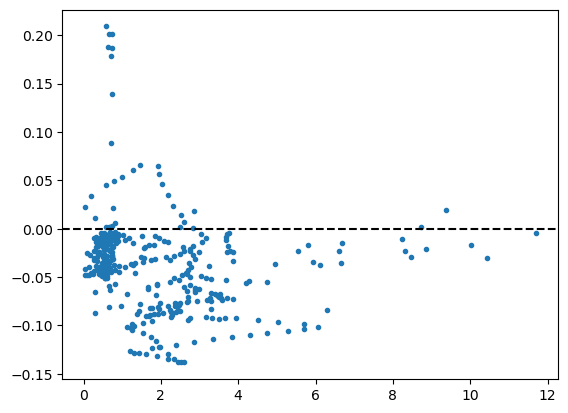

In [28]:
plt.plot(dPdz_dataset.dist_from_core,dPdz_dataset.dPdz,'.');
plt.axhline(0,linestyle='--',c='k')
plt.show()

## Time series vs Distance from core

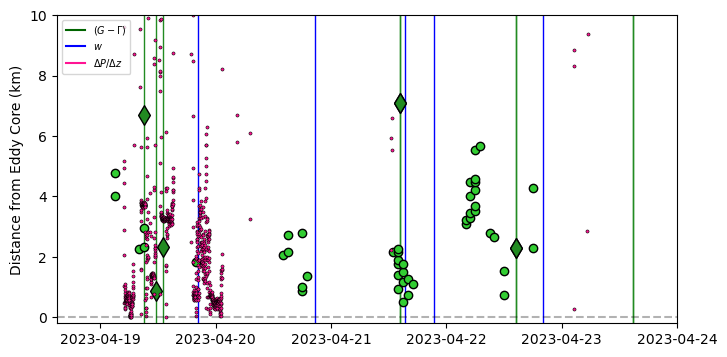

In [57]:
plt.figure(figsize=(8,4))

# dChldt
plt.scatter(dChldt['time'], dChldt['dist_from_core'], marker='o', edgecolor='k', facecolor='limegreen')

# G-Gamma
idx=np.where(bio.depth>0)[0]
plt.scatter(bio['time'][idx],bio['dist_from_core'][idx], s=100, marker='d', edgecolor='k', facecolor='forestgreen')
for t in bio['time'][idx].values:
    plt.axvline(t, linestyle='-', color='forestgreen', lw=1, zorder=0)

# w
for i in range(len(w.time)):
    date_str = str(w['time'][i].values)[0:19]
    dt = datetime.datetime.strptime(date_str, '%Y-%m-%dT%H:%M:%S')
    plt.axvline(dt, linestyle='-', color='b', lw=1, zorder=0)

# dPdz
#dPdz_resampled = dPdz_dataset.resample(time='0.2D').mean('time')
#valid_times = dPdz_resampled['time'].where(~dPdz_resampled['dPdz'].isnull()).dropna(dim='time')
#for t in valid_times.values:
#    plt.axvline(t, linestyle='-', color='deeppink', lw=1, zorder=0)
plt.scatter(dPdz_dataset['time'],dPdz_dataset['dist_from_core'], s=20, marker='.', edgecolor='k', 
            facecolor='deeppink', linewidth=0.4)

# legend
plt.plot([],[],'-',color='darkgreen',label=r'($G-\Gamma$)')
plt.plot([],[],'-',color='blue',label=r'$w$')
plt.plot([],[],'-',color='deeppink',label=r'$\Delta P/\Delta z$')
plt.legend(loc='upper left',fontsize=7)

#  
plt.axhline(0,color='k',linestyle='--',alpha=0.3)
plt.ylabel('Distance from Eddy Core (km)')
plt.xlim(pd.Timestamp('2023-04-18T15'),pd.Timestamp('2023-04-24'))
plt.ylim(-0.2,10) # max distance from eddy

# clusters
cluster1 = ('2023-04-19T00', '2023-04-20T06')
cluster2 = ('2023-04-21T10', '2023-04-21T20')
cluster3 = ('2023-04-22T01', '2023-04-23T05')
#plt.hlines(y=1, xmin=np.datetime64(cluster1[0]), xmax=np.datetime64(cluster1[1]), color='k', lw=2)
#plt.hlines(y=1, xmin=np.datetime64(cluster2[0]), xmax=np.datetime64(cluster2[1]), color='k', lw=2)
#plt.hlines(y=1, xmin=np.datetime64(cluster3[0]), xmax=np.datetime64(cluster3[1]), color='k', lw=2)

#plt.savefig('/Users/elise/Desktop/smode-manuscript-figures/obs-timeseries.png',dpi=800,transparent=True)
plt.show();

## Clustered Budget

In [17]:
def eddy_cluster(ds, times, region):
    #times = ('2023-04-19T05', '2023-04-20T06')
    #region='core' or 'rim'
    ds_ = ds.sel(time=slice(cluster[0],cluster[1]))
    if region == 'core': return ds_.where(ds_['dist_from_core'] <= 4, drop=True)
    elif region == 'rim': return ds_.where((ds_['dist_from_core'] > 4) & (ds_['dist_from_core'] <= 6), drop=True)
    
# select cluster
cluster=cluster1
region='core'
dChldt_ = eddy_cluster(dChldt, cluster,       region=region)
bio_    = eddy_cluster(bio,    cluster,       region=region)
w_      = eddy_cluster(w,      cluster,       region=region); w_=w_.isel(time=0)
dPdz_   = eddy_cluster(dPdz_dataset, cluster, region=region)

if len(dChldt_.dist_from_core)==0 or len(bio_.dist_from_core)==0 or len(w_.dist_from_core)==0 or len(dPdz_.dist_from_core)==0:
    print('oh no!')

In [18]:
# Compute wdPdz with error bars

def product_error(x, y, sigma_x, sigma_y):
    z = x * y
    rel_error = np.sqrt((sigma_x / x)**2 + (sigma_y / y)**2)
    sigma_z = np.abs(z * rel_error)
    return z, sigma_z

# interpolate on same dist_from_core
w_ = w_.assign_coords(dist_from_core=w_['dist_from_core'])

_, idx = np.unique(dPdz_['dist_from_core'], return_index=True)
dPdz_unique = dPdz_.isel(time=idx)
dPdz_swapped = dPdz_unique.swap_dims({'time': 'dist_from_core'})
w_ = w_.sortby('dist_from_core')
dPdz_swapped = dPdz_swapped.sortby('dist_from_core')
common_dist = np.arange(0, 10, 0.1)
w_interp = w_.interp(dist_from_core=common_dist,kwargs={"fill_value": "extrapolate"})
dPdz_interp = dPdz_swapped.interp(dist_from_core=common_dist)

# values + error bars
wdPdz_, wdPdz_err = product_error(w_interp.w_radial_average.values,dPdz_interp.dPdz.values,
                                  np.nanmean(w_interp.w_radial_std),dPdz_interp.dPdz.std().values)
# Create dataset
wdPdz_ = xr.Dataset(
    {'wdPdz': (['dist_from_core'], wdPdz_),
     'wdPdz_err': (['dist_from_core'], wdPdz_err),
    },
    coords={'dist_from_core': (['dist_from_core'], common_dist)}
)
wdPdz_

<xarray.Dataset> Size: 2kB
Dimensions:         (dist_from_core: 100)
Coordinates:
  * dist_from_core  (dist_from_core) float64 800B 0.0 0.1 0.2 ... 9.7 9.8 9.9
Data variables:
    wdPdz           (dist_from_core) float64 800B nan nan nan ... nan nan nan
    wdPdz_err       (dist_from_core) float64 800B nan nan nan ... nan nan nan

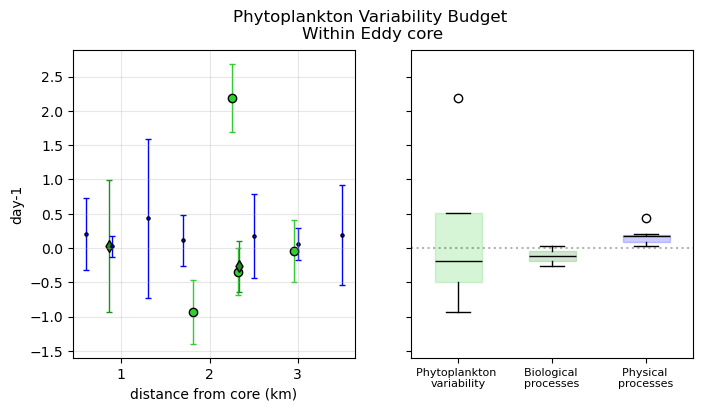

In [19]:
fig, axes = plt.subplots(1,2,figsize=(8,4), sharey=True)

## PLOT 1: raw data
ax=axes[0]
ax.scatter(dChldt_.dist_from_core,dChldt_.dChldt,marker='o',edgecolor='k',facecolor='limegreen')
ax.scatter(bio_.dist_from_core,(bio_.growth+bio_.grazing),marker='d',edgecolor='k',facecolor='forestgreen')
ax.scatter(wdPdz_.dist_from_core,wdPdz_.wdPdz,marker='o',s=5,edgecolor='k',facecolor='blue')

# error bars
dChldt_err = 0.38 * dChldt_.dist_from_ship + 0.15
ax.errorbar(dChldt_.dist_from_core, dChldt_.dChldt, yerr=dChldt_err, fmt='none', markersize=5,
            markerfacecolor='none', markeredgecolor='limegreen', ecolor='limegreen', elinewidth=1, capsize=2,zorder=0)
ax.errorbar(bio_.dist_from_core, (bio_.growth+bio_.grazing), yerr=bio_.grazing_se+bio_.growth_se, fmt='none', markersize=5,
            markerfacecolor='none', markeredgecolor='forestgreen', ecolor='forestgreen', elinewidth=1, capsize=2,zorder=0)
ax.errorbar(wdPdz_.dist_from_core, wdPdz_.wdPdz, yerr=wdPdz_.wdPdz_err, fmt='none', markersize=5,
            markerfacecolor='none', markeredgecolor='b', ecolor='b', elinewidth=1, capsize=2,zorder=0)

ax.set_ylabel('day-1')
ax.set_xlabel('distance from core (km)')
ax.grid(alpha=0.3)

# PLOT 2: box plot
ax=axes[1]
# dChldt
ax.boxplot(
        dChldt_.dChldt, 
        positions=[1],
        widths=0.5,
        patch_artist=True,
        boxprops=dict(facecolor="limegreen", edgecolor='limegreen', alpha=0.2),
        whiskerprops=dict(color="k", linewidth=1), 
        capprops=dict(color="k", linewidth=1),
        medianprops=dict(color="k", linewidth=1) 
    )
# biology
ax.boxplot(
        (bio_.growth+bio_.grazing),
        positions=[2],
        widths=0.5,
        patch_artist=True,
        boxprops=dict(facecolor="forestgreen", edgecolor='forestgreen', alpha=0.2),
        whiskerprops=dict(color="k", linewidth=1), 
        capprops=dict(color="k", linewidth=1),
        medianprops=dict(color="k", linewidth=1) 
    )
# physics
ax.boxplot(
        wdPdz_.wdPdz[~np.isnan(wdPdz_.wdPdz)],
        positions=[3],
        widths=0.5,
        patch_artist=True,
        boxprops=dict(facecolor="b", edgecolor='b', alpha=0.2),
        whiskerprops=dict(color="k", linewidth=1), 
        capprops=dict(color="k", linewidth=1),
        medianprops=dict(color="k", linewidth=1) 
    )
#ax.errorbar(
#    x=3,
#    y=np.median(wdPdz_.wdPdz[~np.isnan(wdPdz_.wdPdz)]), 
#    yerr=wdPdz_.wdPdz_err[~np.isnan(wdPdz_.wdPdz)], 
#    fmt='o',  
#    color='b',  
#    capsize=5,  
#    elinewidth=2,  
#    zorder=10  
#)

ax.axhline(0,c='k',linestyle=':',alpha=0.3)
ax.set_xticks([1,2,3],)
ax.set_xticklabels(['Phytoplankton \nvariability','Biological \nprocesses','Physical \nprocesses'],
                   fontsize=8,rotation=0)
#ax.spines['top'].set_visible(False)
#ax.spines['right'].set_visible(False)

plt.suptitle(f'Phytoplankton Variability Budget \nWithin Eddy {region}')
#plt.savefig('/Users/elise/Desktop//budget_cluster1.png',dpi=800)#,transparent=True)
plt.show()

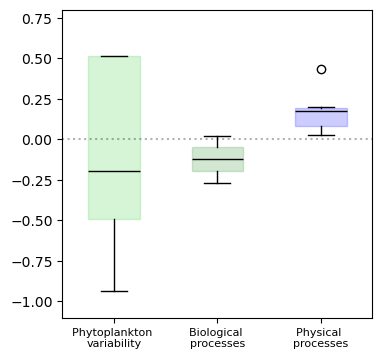

In [20]:
fig, ax = plt.subplots(1,1,figsize=(4,4))
# PLOT 2: box plot
# dChldt
ax.boxplot(
        dChldt_.dChldt, 
        positions=[1],
        widths=0.5,
        patch_artist=True,
        boxprops=dict(facecolor="limegreen", edgecolor='limegreen', alpha=0.2),
        whiskerprops=dict(color="k", linewidth=1), 
        capprops=dict(color="k", linewidth=1),
        medianprops=dict(color="k", linewidth=1) 
    )
# biology
ax.boxplot(
        (bio_.growth+bio_.grazing),
        positions=[2],
        widths=0.5,
        patch_artist=True,
        boxprops=dict(facecolor="forestgreen", edgecolor='forestgreen', alpha=0.2),
        whiskerprops=dict(color="k", linewidth=1), 
        capprops=dict(color="k", linewidth=1),
        medianprops=dict(color="k", linewidth=1) 
    )
# physics
ax.boxplot(
        wdPdz_.wdPdz[~np.isnan(wdPdz_.wdPdz)],
        positions=[3],
        widths=0.5,
        patch_artist=True,
        boxprops=dict(facecolor="b", edgecolor='b', alpha=0.2),
        whiskerprops=dict(color="k", linewidth=1), 
        capprops=dict(color="k", linewidth=1),
        medianprops=dict(color="k", linewidth=1) 
    )

ax.axhline(0,c='k',linestyle=':',alpha=0.3)
ax.set_xticks([1,2,3],)
ax.set_xticklabels(['Phytoplankton \nvariability','Biological \nprocesses','Physical \nprocesses'],
                   fontsize=8,rotation=0)
#ax.spines['top'].set_visible(False)
#ax.spines['right'].set_visible(False)
ax.set_ylim(-1.1,0.8)
plt.show()


## Paper figure -- Time series vs Rate

/var/folders/vw/s5yfsczj0nzgw4mcs35y8c9r0000gp/T/ipykernel_34407/1011557355.py:93: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  custom_dates = pd.date_range(start='2023-04-17T18', end='2023-04-24T18', freq='12H')  # Daily frequency


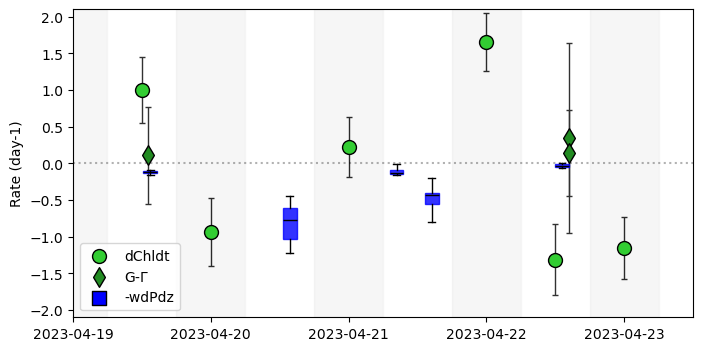

136 values


In [42]:
import matplotlib.dates as mdates
import pandas as pd
import datetime

# Product Error for wdPdz
def product_error(x, y, sigma_x, sigma_y):
    z = x * y
    rel_error = np.sqrt((sigma_x / x)**2 + (sigma_y / y)**2)
    sigma_z = np.abs(z * rel_error)
    return z, sigma_z

# Select Eddy Core Region
def eddy_region(ds, region):
    if region == 'core': return ds.where(ds['dist_from_core'] <= 4, drop=True)
    elif region == 'rim': return ds.where((ds['dist_from_core'] > 3) & (ds['dist_from_core'] <= 6), drop=True)

dChldt_ = eddy_region(dChldt,'core')
bio_    = eddy_region(biology_data,'core')
w_      = eddy_region(w, 'core')
                    
# Treat dPdz as a constant
dPdz_cst = dPdz_dataset.dPdz.mean().values
dPdz_std = dPdz_dataset.dPdz.std().values

# Plot all Rates
n=0
plt.figure(figsize=(8,4))
plt.rcParams["pdf.fonttype"] = 42

# dChldt
dChldt_['time'] = dChldt_.time + np.timedelta64(7, 'h') # convert to local time
dChldt_ = dChldt_.resample(time='1h').mean('time')
times = pd.to_datetime(dChldt_['time'].values).to_pydatetime()
dChldt_err = 0.38 * dChldt_.dist_from_ship + 0.15
plt.scatter(times, dChldt_['dChldt'], s=100, marker='o', edgecolor='k', facecolor='limegreen', zorder=101, alpha=0.)
plt.errorbar(times, dChldt_['dChldt'], yerr=dChldt_err, fmt='none', markersize=5,
            markerfacecolor='none', markeredgecolor='limegreen', ecolor='k', elinewidth=1, capsize=2,zorder=0, alpha=0.)
n+=len(dChldt_.dChldt.values.flatten())

# dChldt 12h
grouped_12h = dChldt_.resample(time='12h', offset='6h')
median_12h = grouped_12h.median()
stderr_12h = grouped_12h.std() / np.sqrt(grouped_12h.count())
median_12h['time'] = median_12h['time'] + np.timedelta64(6, 'h')
dChldt_err = 0.38 * median_12h.dist_from_ship + 0.15
plt.scatter(median_12h.time, median_12h.dChldt, s=100, marker='o', edgecolor='k', facecolor='limegreen', zorder=101)
plt.errorbar(median_12h.time.values, median_12h.dChldt.values, yerr=dChldt_err.values, fmt='none', 
             markersize=5, markerfacecolor='none', markeredgecolor='limegreen', 
             ecolor='k', elinewidth=1, capsize=2, zorder=0)

# G-Gamma
times = pd.to_datetime(bio_['time'].values).to_pydatetime()
idx=np.where(bio_.depth<=11)[0]
plt.scatter(times[idx],(bio_['growth']+bio_['grazing'])[idx], s=100, marker='d', edgecolor='k', facecolor='forestgreen', zorder=101)
plt.errorbar(times[idx], (bio_['growth']+bio_['grazing'])[idx], yerr=(bio_['grazing_se']+bio_['growth_se'])[idx], fmt='none', markersize=5,
            markerfacecolor='none', markeredgecolor='forestgreen', ecolor='k', elinewidth=1, capsize=2,zorder=0)
#for t in bio_['time'][idx].values:
#    plt.axvline(t, linestyle='-', color='forestgreen', lw=1, zorder=0)
n+=len(bio_.grazing.values.flatten())

# wdPdz
wdPdz_total=[]
times=pd.to_datetime(w_['time'].values).tz_localize('UTC').tz_convert('America/Los_Angeles').to_pydatetime()
for i in range(len(w_.time)):
    dt = date_str = str(times[i])[0:19]
    dt = datetime.datetime.strptime(date_str, '%Y-%m-%d %H:%M:%S')
    #plt.axvline(dt, linestyle='-', color='b', lw=1, zorder=0)
    wdPdz_, wdPdz_err = product_error(w_['w_radial_average'][i,:].values.flatten(),dPdz_cst,
                                      w_['w_radial_std'][i,:].values.flatten(),dPdz_std)
    wdPdz_*=-1
    wdPdz_total.append(wdPdz_)
    plt.boxplot(
        [wdPdz_],
        positions= [mdates.date2num(dt)],
        widths=0.1,
        patch_artist=True,
        boxprops=dict(facecolor="b", edgecolor='b', alpha=0.8),
        whiskerprops=dict(color="k", linewidth=1), 
        capprops=dict(color="k", linewidth=1),
        medianprops=dict(color="k", linewidth=1),
        whis=(0, 100)
    )
n+=len(w_.w_radial_average.values.flatten())
#for d in range(len(w_['dist_from_core'])):
    #plt.scatter(w_['time'], (w_['w_radial_average']*dPdz_cst)[:,d], marker='o', edgecolor='k', facecolor='b')
    #wdPdz_, wdPdz_err = product_error(w_['w_radial_average'][:,d].values,dPdz_cst,w_['w_radial_std'][:,d].values,dPdz_std)
    #plt.errorbar(w_['time'], (w_['w_radial_average']*dPdz_cst)[:,d], yerr=wdPdz_err, fmt='none', markersize=5,
    #        markerfacecolor='none', markeredgecolor='b', ecolor='b', elinewidth=1, capsize=2,zorder=0)


# Add shading between days
custom_dates = pd.date_range(start='2023-04-18', end='2023-04-24', freq='1D')  # Daily frequency
custom_dates = pd.date_range(start='2023-04-17T18', end='2023-04-24T18', freq='12H')  # Daily frequency
for i in range(len(custom_dates) - 1):
    start_day, end_day = custom_dates[i], custom_dates[i + 1]
    color = 'lightgrey' if i % 2 == 0 else 'white' # alternate colors
    plt.axvspan(start_day, end_day, color=color, alpha=0.2, zorder=0)


# legend
plt.scatter([],[],marker='o',facecolor='limegreen',edgecolor='k',s=100,label='dChldt')
plt.scatter([],[],marker='d',facecolor='forestgreen',edgecolor='k',s=100,label=r'G-$\Gamma$')
plt.scatter([],[],marker='s',facecolor='b',edgecolor='k',s=100,label='-wdPdz')
#plt.plot([],[],'-',color='darkgreen',label=r'($G-\Gamma$)')
#plt.plot([],[],'-',color='blue',label=r'$wdPdz$')
plt.legend(loc='lower left',fontsize=10)

#  
plt.axhline(0,color='k',linestyle=':',alpha=0.3)
plt.ylabel('Rate (day-1)')
plt.xlim(pd.Timestamp('2023-04-19T00'),pd.Timestamp('2023-04-23T12'))
plt.ylim(-2.1,2.1)

# xticks
timestamps = [
    datetime.datetime(2023, 4, 19, 00),
    datetime.datetime(2023, 4, 20, 00),
    datetime.datetime(2023, 4, 21, 00),
    datetime.datetime(2023, 4, 22, 00),
    datetime.datetime(2023, 4, 23, 00),
]
date_nums = mdates.date2num(timestamps)
plt.gca().set_xticks(date_nums)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
#plt.savefig('/Users/elise/Desktop/rates-timeseries.png',dpi=800)#,transparent=True)
#plt.savefig('/Users/elise/ocean/drifters_chl/high-res/fig4/fig4a_newdata.pdf')
plt.show();
#print(bio_.dist_from_core.values)
print(f'{n} values')


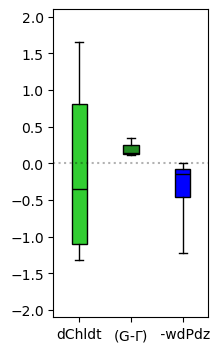

In [44]:
fig, ax = plt.subplots(1,1,figsize=(2,4))
plt.rcParams["pdf.fonttype"] = 42
width=0.3; alpha=1
# PLOT 2: box plot
# dChldt
ax.boxplot(
        median_12h.dChldt[~np.isnan(median_12h.dChldt)], 
        positions=[1],
        widths=width,
        patch_artist=True,
        boxprops=dict(facecolor="limegreen", edgecolor='k', alpha=alpha),
        whiskerprops=dict(color="k", linewidth=1), 
        capprops=dict(color="k", linewidth=1),
        medianprops=dict(color="k", linewidth=1),
        whis=(0, 100)
    )
# biology
ax.boxplot(
        (bio_.growth+bio_.grazing)[idx],
        positions=[2],
        widths=width,
        patch_artist=True,
        boxprops=dict(facecolor="forestgreen", edgecolor='k', alpha=alpha),
        whiskerprops=dict(color="k", linewidth=1), 
        capprops=dict(color="k", linewidth=1),
        medianprops=dict(color="k", linewidth=1),
        whis=(0, 100)
    )

# physics
ax.boxplot(
        np.concatenate(wdPdz_total),
        positions=[3],
        widths=width,
        patch_artist=True,
        boxprops=dict(facecolor="b", edgecolor='k', alpha=alpha),
        whiskerprops=dict(color="k", linewidth=1), 
        capprops=dict(color="k", linewidth=1),
        medianprops=dict(color="k", linewidth=1),
        whis=(0, 100)
    )

ax.axhline(0,c='k',linestyle=':',alpha=0.3)
ax.set_xticks([1,2,3],)
#ax.set_xticklabels(['Phytoplankton \nvariability','Biological \nprocesses','Physical \nprocesses'],
#                   fontsize=8,rotation=0)
ax.set_xticklabels(['dChldt',r'(G-$\Gamma$)',' -wdPdz'],
                   fontsize=10,rotation=0)
plt.ylim(-2.1,2.1)
#plt.savefig('/Users/elise/Desktop/rates-ranges.png',dpi=800)#,transparent=True)
#plt.savefig('/Users/elise/ocean/drifters_chl/high-res/fig4/fig4b_newdata.pdf',bbox_inches='tight')
plt.show()


In [45]:
bio_.growth+bio_.grazing

<xarray.DataArray (time: 3)> Size: 24B
array([0.10934847, 0.34435567, 0.14122552])
Coordinates:
    dist_from_core  (time) float64 24B 2.328 2.287 2.287
  * time            (time) datetime64[ns] 24B 2023-04-19T12:59:00 ... 2023-04...

<ErrorbarContainer object of 3 artists>

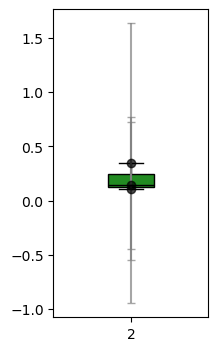

In [37]:
fig, ax = plt.subplots(1,1,figsize=(2,4))
data = bio_.growth + bio_.grazing
errors = bio_.growth_se + bio_.grazing_se  # or other appropriate error estimate
positions = 2  # matching the boxplot position

ax.boxplot(
    data[idx],
    positions=[positions],
    widths=width,
    patch_artist=True,
    boxprops=dict(facecolor="forestgreen", edgecolor='k', alpha=alpha),
    whiskerprops=dict(color="k", linewidth=1),
    capprops=dict(color="k", linewidth=1),
    medianprops=dict(color="k", linewidth=1),
    whis=(0, 100)
)

ax.errorbar(
    x=np.full_like(data[idx], positions),  # x-position aligned with boxplot
    y=data[idx],
    yerr=errors[idx],
    fmt='o',  # marker style
    color='black',
    ecolor='gray',
    alpha=0.7,
    capsize=3,
    label='Individual data with error bars'
)


In [35]:
(bio_.growth+bio_.grazing)[idx]

<xarray.DataArray (time: 3)> Size: 24B
array([0.10934847, 0.34435567, 0.14122552])
Coordinates:
    dist_from_core  (time) float64 24B 2.328 2.287 2.287
  * time            (time) datetime64[ns] 24B 2023-04-19T12:59:00 ... 2023-04...

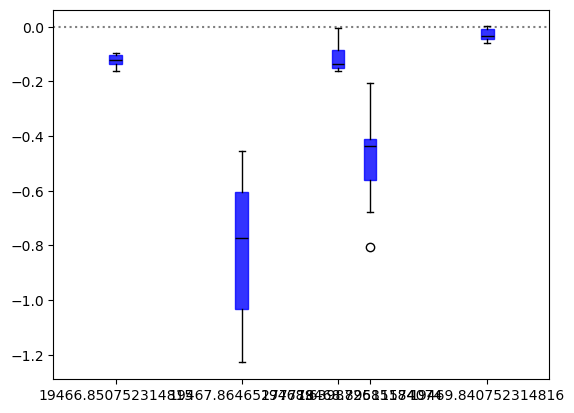

In [33]:
# wdPdz
for i in range(len(w_.time)):
    date_str = str(w_['time'][i].values)[0:19]
    dt = datetime.datetime.strptime(date_str, '%Y-%m-%dT%H:%M:%S')
    #plt.axvline(dt, linestyle='-', color='b', lw=1, zorder=0)
    wdPdz_, wdPdz_err = product_error(w_['w_radial_average'][i,:].values.flatten(),dPdz_cst,
                                      w_['w_radial_std'][i,:].values.flatten(),dPdz_std)
    wdPdz_*=-1
    plt.boxplot(
        [wdPdz_],
        positions= [mdates.date2num(dt)],
        widths=0.1,
        patch_artist=True,
        boxprops=dict(facecolor="b", edgecolor='b', alpha=0.8),
        whiskerprops=dict(color="k", linewidth=1), 
        capprops=dict(color="k", linewidth=1),
        medianprops=dict(color="k", linewidth=1))

plt.axhline(0,c='k',linestyle=':',alpha=0.5)
plt.show();